In [8]:
from google.colab import files
uploaded = files.upload()

Saving dataset_elec (1).mat to dataset_elec (1) (1).mat
Saving dataset_amb (3).mat to dataset_amb (3) (1).mat


Files 'dataset_elec (1).mat' and 'dataset_amb (3).mat' loaded successfully.

--- 2. Exploratory Data Analysis (EDA) ---

Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373798 entries, 0 to 1373797
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   vdc1         1373798 non-null  float64
 1   vdc2         1373798 non-null  float64
 2   idc1         1373798 non-null  float64
 3   idc2         1373798 non-null  float64
 4   irr          1373798 non-null  float64
 5   pvt          1373798 non-null  float64
 6   Fault_Label  1373798 non-null  uint8  
dtypes: float64(6), uint8(1)
memory usage: 64.2 MB
*************************************************************************************

DataFrame Head:
     vdc1    vdc2    idc1    idc2     irr     pvt  Fault_Label
0  0.7143  0.5550  0.0608  0.0073  1.3729  2.3816            0
1  0.6944  0.5427  0.0615  0.0064  1.3604  2.3816            0
2  

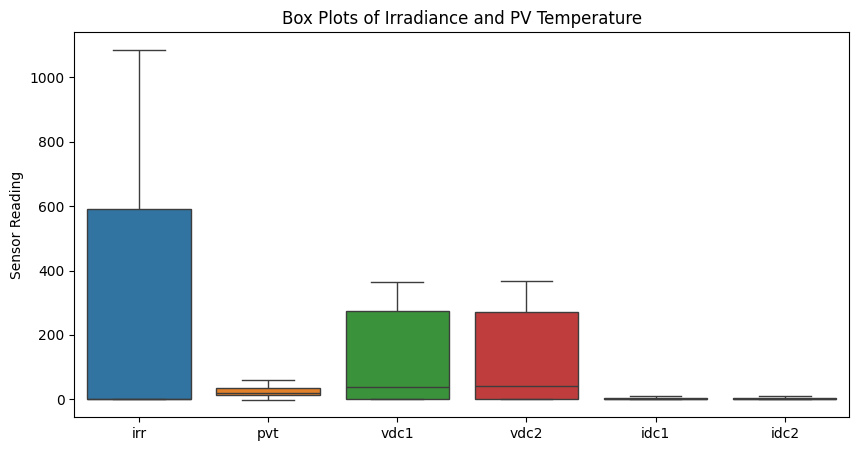


--- 3. Visualization ---


/tmp/ipython-input-257774178.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fault_Label', data=df, palette='viridis', order=sorted(df['Fault_Label'].unique()))


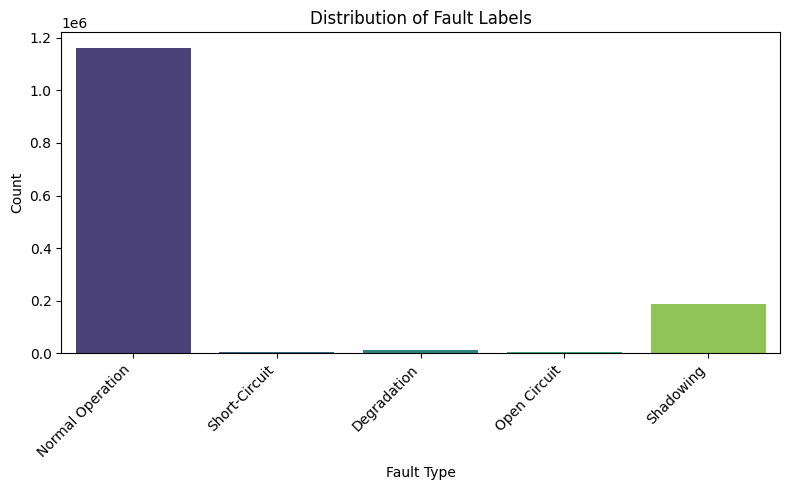


--- Feature Scaling:Z-score Standardization ---

-Time-Based Data Split (80/20) ---
Training set size: 1099038 samples.
Test set size: 274760 samples.

--- 4. B. Feature Scaling (StandardScaler) ---
Status: All 6 features successfully scaled (Z-score).


In [14]:
# Install necessary libraries if not already installed (Colab usually has these)
# !pip install scipy pandas numpy matplotlib seaborn

import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Files
FILE_ELEC = 'dataset_elec (1).mat'
FILE_AMB = 'dataset_amb (3).mat'

#File Handling
try:
    elec_data = scipy.io.loadmat(FILE_ELEC)
    amb_data = scipy.io.loadmat(FILE_AMB)
    print(f"Files '{FILE_ELEC}' and '{FILE_AMB}' loaded successfully.")

except FileNotFoundError:
    print("\n--- ERROR ---")
    print(f"File not found. Please ensure you have uploaded '{FILE_ELEC}' and '{FILE_AMB}'")
    print("to the Colab environment using 'from google.colab import files; files.upload()' first.")
    raise

# --- Extract and store the data to a single dataFrame----
data = {}

# Electrical data keys: 'vdc1', 'vdc2', 'idc1', 'idc2'
for key in ['vdc1', 'vdc2', 'idc1', 'idc2']:
    data[key] = elec_data[key].flatten()

# Ambient and Fault data keys: 'irr', 'pvt', 'f_nv'
for key in ['irr', 'pvt', 'f_nv']:
    data[key] = amb_data[key].flatten()

# DataFrame creation
df = pd.DataFrame(data)
df = df.rename(columns={'f_nv': 'Fault_Label'})

# --- 2. Exploratory Data Analysis (EDA) ---
print("\n--- 2. Exploratory Data Analysis (EDA) ---")

print("\nCombined DataFrame Info:")
df.info()
print("*************************************************************************************")
print("\nDataFrame Head:")
print(df.head())
print("*************************************************************************************")

# Descriptive Statistics
print("\nDescriptive Statistics for Features:")
print(df.drop(columns=['Fault_Label']).describe())
print("*************************************************************************************")

# Fault Label Mapping
fault_map = {
    0: 'Normal Operation',
    1: 'Short-Circuit',
    2: 'Degradation',
    3: 'Open Circuit',
    4: 'Shadowing'
}
df['Fault_Name'] = df['Fault_Label'].map(fault_map)

# Fault Distribution
print("\nFault Label Distribution:")
print(df['Fault_Name'].value_counts().sort_index())
print("*************************************************************************************")

# Check for Missing Values
print("\nMissing values per column (must be zero):")
print(df.isnull().sum())
print("*************************************************************************************")


# --- 3. Outlier Visualization (Box Plots for Key Features) ---
print("\n--- 3. Outlier Visualization ---")

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['irr', 'pvt','vdc1', 'vdc2', 'idc1', 'idc2']])
plt.title('Box Plots of Irradiance and PV Temperature')
plt.ylabel('Sensor Reading')
plt.show()
print("*************************************************************************************")





# --- 3. Visualization ---
print("\n--- 3. Visualization ---")

# 3.1. Fault Distribution Count Plot
plt.figure(figsize=(8, 5))
sns.countplot(x='Fault_Label', data=df, palette='viridis', order=sorted(df['Fault_Label'].unique()))
plt.xticks(ticks=sorted(df['Fault_Label'].unique()), labels=[fault_map[i] for i in sorted(fault_map.keys())], rotation=45, ha='right')
plt.title('Distribution of Fault Labels')
plt.xlabel('Fault Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("*************************************************************************************")



#------------------Feature Scaling:Z-score Standardization------------
print("\n--- Feature Scaling:Z-score Standardization ---")

print("\n-Time-Based Data Split (80/20) ---")
FEATURE_COLS = ['vdc1', 'vdc2', 'idc1', 'idc2', 'irr', 'pvt']

X = df[FEATURE_COLS].values
y = df['Fault_Label'].values

train_size = int(0.8 * len(df))
X_train_flat, X_test_flat = X[:train_size], X[train_size:]
y_train_flat, y_test_flat = y[:train_size], y[train_size:]

print(f"Training set size: {len(X_train_flat)} samples.")
print(f"Test set size: {len(X_test_flat)} samples.")


# B. Feature Scaling (Z-score Standardization)
print("\n--- 4. B. Feature Scaling (StandardScaler) ---")

scaler = StandardScaler()

scaler.fit(X_train_flat)

# Transform both training and test sets
X_train_scaled = scaler.transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

print("Status: All 6 features successfully scaled (Z-score).")





In [ ]:
from google.colab import drive
drive.mount('/content/drive')